In [1]:
import numpy as np                    # Import NumPy for numerical operations
import pandas as pd                   # Import Pandas for data manipulation and analysis
import seaborn as sns                 # Import Seaborn for statistical data visualization
import matplotlib.pyplot as plt       # Import Matplotlib for creating charts and visualizations

In [4]:
# Load the Bank Customer Churn dataset into a DataFrame
df = pd.read_csv("Bank_Customer_Churn.csv")
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Active_Status,EstimatedSalary,Exited,Exited_Status
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,Yes,101348.88,1,Yes
1,15651315,Dilke,627,France,Male,41,3,0.00,2,1,0,No,132719.80,0,No
2,15757632,Hughes-Jones,496,France,Female,41,1,176024.05,2,1,0,No,182337.98,0,No
3,15596972,Brownlow,534,France,Male,38,3,0.00,1,0,0,No,143938.27,0,No
4,15568982,Hao,726,France,Female,24,6,0.00,2,1,1,Yes,54724.03,0,No


In [111]:
# Remove unnecessary columns from the DataFrame
df.drop(columns=['RowNumber', 'Unnamed: 14', 'Unnamed: 15'], inplace=True)
df.head()

KeyError: "['RowNumber', 'Unnamed: 14', 'Unnamed: 15'] not found in axis"

In [6]:
# Display information about the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  Active_Status    10000 non-null  object 
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
 14  Exited_Status    10000 non-null  object 
dtypes: float64(2), int64(8), object(5)
memory usage: 1.1+ MB


In [7]:
# Create new column Exited_Status
df['Exited_Status'] = df['Exited'].map({0: 'No', 1: 'Yes'})

# Create new column Active_Status
df['Active_Status'] = df['IsActiveMember'].map({0: 'No', 1: 'Yes'})
cols = list(df.columns)
cols.insert(cols.index('IsActiveMember') + 1, cols.pop(cols.index('Active_Status')))
df = df[cols]
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Active_Status,EstimatedSalary,Exited,Exited_Status
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,Yes,101348.88,1,Yes
1,15651315,Dilke,627,France,Male,41,3,0.00,2,1,0,No,132719.80,0,No
2,15757632,Hughes-Jones,496,France,Female,41,1,176024.05,2,1,0,No,182337.98,0,No
3,15596972,Brownlow,534,France,Male,38,3,0.00,1,0,0,No,143938.27,0,No
4,15568982,Hao,726,France,Female,24,6,0.00,2,1,1,Yes,54724.03,0,No


In [8]:
# Check the number of rows and columns in the DataFrame
df.shape

(10000, 15)

In [9]:
# Display information about the DataFrame, including columns, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  Active_Status    10000 non-null  object 
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
 14  Exited_Status    10000 non-null  object 
dtypes: float64(2), int64(8), object(5)
memory usage: 1.1+ MB


In [10]:
# Generate descriptive statistics for the numerical columns in the DataFrame
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [11]:
# Display the first 20 rows of the DataFrame
df.head(20)

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Active_Status,EstimatedSalary,Exited,Exited_Status
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,Yes,101348.88,1,Yes
1,15651315,Dilke,627,France,Male,41,3,0.00,2,1,0,No,132719.80,0,No
2,15757632,Hughes-Jones,496,France,Female,41,1,176024.05,2,1,0,No,182337.98,0,No
3,15596972,Brownlow,534,France,Male,38,3,0.00,1,0,0,No,143938.27,0,No
4,15568982,Hao,726,France,Female,24,6,0.00,2,1,1,Yes,54724.03,0,No
5,15633818,McMillan,786,France,Male,32,9,0.00,2,1,0,No,133112.41,0,No
6,15660200,Mai,551,France,Male,31,1,0.00,2,1,1,Yes,185105.44,0,No
7,15585777,Pai,710,France,Male,38,3,130588.82,1,1,1,Yes,154997.64,0,No
8,15665064,Harvey,523,France,Male,36,8,158351.02,2,1,0,No,155304.53,0,No
9,15726087,Ch'in,592,France,Female,62,5,0.00,1,1,1,Yes,100941.57,0,No


In [12]:
# Check the number of missing (null) values in each column
df.isnull().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
Active_Status      0
EstimatedSalary    0
Exited             0
Exited_Status      0
dtype: int64

In [15]:
# Remove duplicate rows from the DataFrame
df.drop_duplicates(inplace = True)

In [16]:
# Sort the DataFrame by the Geography column in ascending order
df = df.sort_values(by = "Geography")
df.head(500)

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,Active_Status,EstimatedSalary,Exited,Exited_Status
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,Yes,101348.88,1,Yes
3346,15809509,Venables,699,France,Male,29,3,125689.29,1,1,1,Yes,151623.71,0,No
3345,15757865,Powell,642,France,Male,62,7,0.00,2,1,1,Yes,61120.75,0,No
3344,15638730,Macleod,711,France,Female,21,0,82844.33,2,0,1,Yes,1408.68,0,No
3343,15736717,Ma,602,France,Male,31,7,155271.83,1,1,1,Yes,179446.31,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3517,15723720,McKenzie,591,France,Female,31,7,0.00,2,0,1,Yes,48778.46,0,No
3516,15744105,Kodilinyechukwu,768,France,Female,28,3,109118.05,2,0,1,Yes,50911.41,0,No
3487,15802593,Little,504,France,Female,49,7,0.00,3,0,1,Yes,87822.14,1,Yes
3515,15776223,Davide,597,France,Female,42,4,64740.12,1,1,1,Yes,106841.12,0,No


In [17]:
# Display the column names of the DataFrame
df.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'Active_Status', 'EstimatedSalary', 'Exited', 'Exited_Status'],
      dtype='object')

In [40]:
# Count the number of non-null values in the CustomerId column
Total_Customers = print(df['CustomerId'].count())
Total_Customers

10000


In [41]:
# Count the number of customers who have exited
Customer_Exited = print(df[df['Exited_Status'] == 'Yes']['CustomerId'].count())
Customer_Exited

2037


In [53]:
# Calculate and display the percentage of customers who exited
Churn_Rate = print(f"{round((df[df['Exited_Status'] == 'Yes']['CustomerId'].count()/df['CustomerId'].count())*100, 2)}%")
Churn_Rate

20.37%


In [51]:
# Calculate and display the average customer balance in dollars
Average_Balance = print(f"${df['Balance'].mean():.2f}")
Average_Balance

$76485.89


In [57]:
# Calculate and round the average credit score
Average_Credit_Score = round(df['CreditScore'].mean())
Average_Credit_Score

651

## CUSTOMER CHURN DISTRIBUTION ACROSS GEOGRAPHY AND GENDER

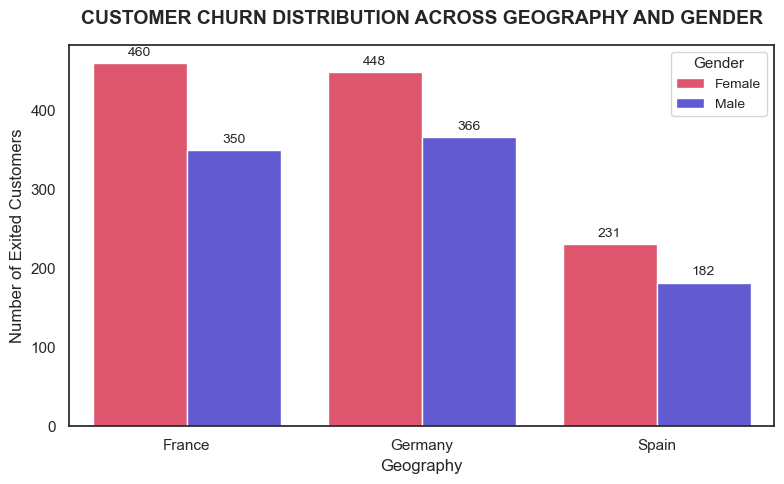

In [123]:
# 1) Filter the dataset for customers where Exited_Status is 'Yes'
df_exited = df[df['Exited_Status'] == 'Yes']

# 2) Set the aesthetic style of the plots (Changed to 'white' to remove gridlines)
sns.set_theme(style='white')

# 3) Create the grouped bar chart
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df_exited,
    x='Geography',
    hue='Gender',
    palette=['#F43F5E', '#4F46E5'],  # Custom colors for genders
)

# 4) Customize labels and title
plt.title(
    'CUSTOMER CHURN DISTRIBUTION ACROSS GEOGRAPHY AND GENDER',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Geography', fontsize=12)
plt.ylabel('Number of Exited Customers', fontsize=12)
plt.legend(title='Gender', title_fontsize='11', fontsize='10')

# Optional: Add data labels on top of the bars
for p in ax.patches:
  height = p.get_height()
  if height > 0:
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2.0, height),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(0, 3),
        textcoords='offset points',
    )

plt.tight_layout()
plt.show()

## CUSTOMER BASE DEMOGRAPHICS BY GENDER

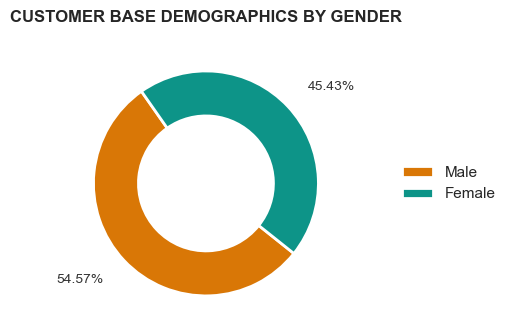

In [121]:
# 1) Calculate value counts for the Gender column
gender_counts = df['Gender'].value_counts()

# 2) Set up the figure size
plt.figure(figsize=(6, 3.5))

# 3) Define custom colors (Orange and Teal)
colors = ['#d97706', '#0d9488']

# 4) Create the donut chart with labels pushed outside (Rotated by 35° -> 90 + 35 = 125)
wedges, texts, autotexts = plt.pie(
    gender_counts,
    autopct='%1.2f%%',
    startangle=125,  # Rotated 35 degrees counter-clockwise from 90°
    colors=colors,
    pctdistance=1.25,  # Pushes the percentage text outside the donut
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
)

# 5) Format text properties and alignment for outside labels
for i, autotext in enumerate(autotexts):
  # Get the angle of each wedge to determine side (left or right)
  angle = (wedges[i].theta2 - wedges[i].theta1) / 2.0 + wedges[i].theta1
  x = np.cos(np.deg2rad(angle))

  # Align text properly depending on which side of the chart it falls on
  ha = 'right' if x < 0 else 'left'
  autotext.set_horizontalalignment(ha)
  autotext.set_fontsize(10)
  autotext.set_color('#333333')

# 6) Add a legend on the right side
plt.legend(
    wedges,
    gender_counts.index,
    loc='center left',
    bbox_to_anchor=(1.15, 0.5),
    frameon=False,
)

# 7) Add title and layout adjustments
plt.title(
    'CUSTOMER BASE DEMOGRAPHICS BY GENDER', fontsize=12, fontweight='bold', pad=15
)
plt.tight_layout()
plt.show()

## CREDIT CARD OWNERSHIP DISTRIBUTION

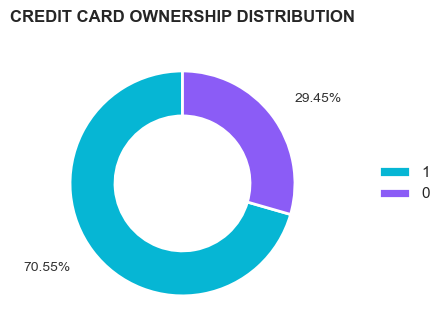

In [122]:
# 1) Calculate value counts for the HasCrCard column
card_counts = df['HasCrCard'].value_counts()

# 2) Set up the figure size
plt.figure(figsize=(6, 3.5))

# 3) Define custom colors (Cyan for 1, Purple for 0) matching your chart
colors = ['#06b6d4', '#8b5cf6']

# 4) Create the donut chart with labels pushed outside
wedges, texts, autotexts = plt.pie(
    card_counts,
    autopct='%1.2f%%',
    startangle=90,
    colors=colors,
    pctdistance=1.25,  # Pushes the percentage text outside the donut
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
)

# 5) Format text properties and alignment for outside labels
for i, autotext in enumerate(autotexts):
  # Get the angle of each wedge to dynamically align left or right
  angle = (wedges[i].theta2 - wedges[i].theta1) / 2.0 + wedges[i].theta1
  x = np.cos(np.deg2rad(angle))

  ha = 'right' if x < 0 else 'left'
  autotext.set_horizontalalignment(ha)
  autotext.set_fontsize(10)
  autotext.set_color('#333333')

# 6) Add a legend on the right side
plt.legend(
    wedges,
    card_counts.index,
    loc='center left',
    bbox_to_anchor=(1.15, 0.5),
    frameon=False,
)

# 7) Add title and layout adjustments
plt.title('CREDIT CARD OWNERSHIP DISTRIBUTION', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [82]:
# Display the maximum balance value in the DataFrame
Highest_Balance = print(df['Balance'].max())

250898.09


In [116]:
# Display the maximum credit score
High_Credit_Score = print(df['CreditScore'].max())
High_Credit_Score

# Display the minimum credit score
Low_Credit_Score = print(df['CreditScore'].min())
Low_Credit_Score

850
350


In [86]:
# Calculate and display the average estimated salary in dollars
Average_Customer_Salary = print(f"${df['EstimatedSalary'].mean():.2f}")
Average_Customer_Salary

$100090.24


In [89]:
# Calculate and display the total number of products held by all customers
Number_of_Products = print(df['NumOfProducts'].sum())
Number_of_Products

15302


## CHURN DISTRIBUTION ACROSS AGE BRACKETS AND REGIONS

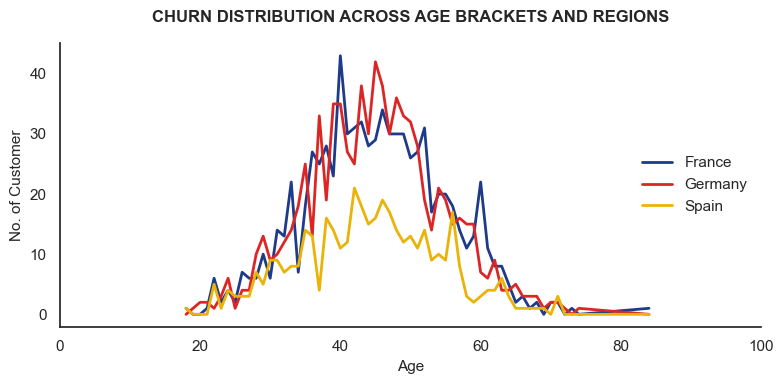

In [93]:
# 1) Filter the dataset for customers where Exited_Status is 'Yes'
df_exited = df[df['Exited_Status'] == 'Yes']

# 2) Group by Age and Geography to get the count of customers
churn_age_geo = (
    df_exited.groupby(['Age', 'Geography']).size().unstack(fill_value=0)
)

# 3) Set up the figure size and clean white theme
plt.figure(figsize=(8, 4))
sns.set_theme(style='white')

# 4) Define custom colors for each region to match your reference chart
colors = {
    'France': '#1e3a8a',  # Dark Blue
    'Germany': '#dc2626',  # Red
    'Spain': '#eab308',  # Yellow/Gold
}

# 5) Plot lines for each geography column available in the data
for geo in churn_age_geo.columns:
  if geo in colors:
    plt.plot(
        churn_age_geo.index,
        churn_age_geo[geo],
        label=geo,
        color=colors[geo],
        linewidth=2,
    )

# 6) Customize title, labels, and axes limits
plt.title(
    'CHURN DISTRIBUTION ACROSS AGE BRACKETS AND REGIONS',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Age', fontsize=11)
plt.ylabel('No. of Customer', fontsize=11)
plt.xlim(0, 100)  # Extends x-axis scale up to 100 as shown in your target image

# 7) Add legend and clean borders
plt.legend(frameon=False, loc='center right')
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

## IMPACT OF PRODUCT VOLUME ON CHURN RATE

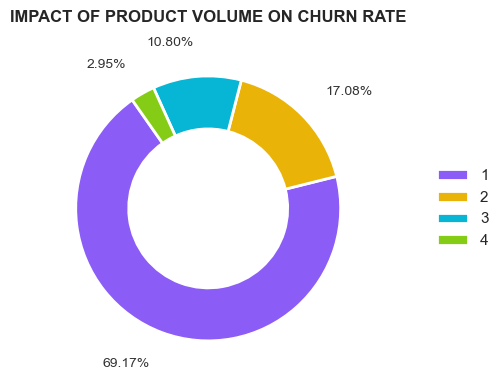

In [112]:
# 1) Filter the dataset for customers where Exited_Status is 'Yes'
df_exited = df[df['Exited_Status'] == 'Yes']

# 2) Calculate value counts for the NumOfProducts column and sort by product index
product_counts = df_exited['NumOfProducts'].value_counts().sort_index()

# 3) Set up the figure size
plt.figure(figsize=(7, 4))

# 4) Define custom colors (Purple, Gold, Turquoise, Light Green) matching the reference
colors = ['#8b5cf6', '#eab308', '#06b6d4', '#84cc16']

# 5) Create the donut chart with labels pushed outside (Rotated by 35° -> 90 + 35 = 125)
wedges, texts, autotexts = plt.pie(
    product_counts,
    autopct='%1.2f%%',
    startangle=125,  # Rotated 35 degrees counter-clockwise from 90°
    colors=colors,
    pctdistance=1.25,  # Pushes percentage text outside the donut ring
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
)

# 6) Format text properties and alignment for outside labels
for i, autotext in enumerate(autotexts):
  # Calculate wedge angle to dynamically set alignment left or right
  angle = (wedges[i].theta2 - wedges[i].theta1) / 2.0 + wedges[i].theta1
  x = np.cos(np.deg2rad(angle))

  ha = 'right' if x < 0 else 'left'
  autotext.set_horizontalalignment(ha)
  autotext.set_fontsize(10)
  autotext.set_color('#333333')

# 7) Add a legend on the right side for the product quantities
plt.legend(
    wedges,
    product_counts.index,
    loc='center left',
    bbox_to_anchor=(1.15, 0.5),
    frameon=False,
)

# 8) Add title and layout adjustments
plt.title(
    'IMPACT OF PRODUCT VOLUME ON CHURN RATE',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
plt.tight_layout()
plt.show()

## CREDIT SCORE AND BALANCE ANALYSIS BY EXIT STATUS

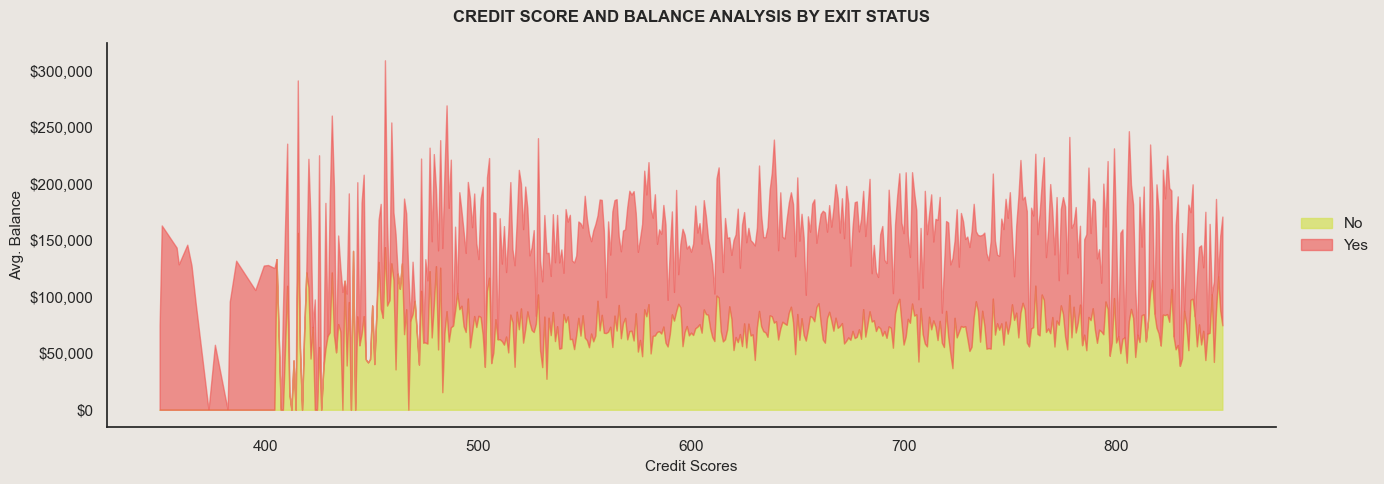

In [119]:
# 1) Group data by CreditScore and Exited_Status, calculating the average balance
pivot_df = (
    df.groupby(['CreditScore', 'Exited_Status'])['Balance']
    .mean()
    .unstack(fill_value=0)
)

# Ensure both 'No' and 'Yes' columns exist
for status in ['No', 'Yes']:
  if status not in pivot_df.columns:
    pivot_df[status] = 0

# Sort columns so 'No' is stacked at the bottom and 'Yes' is stacked on top
pivot_df = pivot_df[['No', 'Yes']]

# 2) Set up the figure and styling matching your image background
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#EAE6E1')
ax.set_facecolor('#EAE6E1')

# 3) Plot as a Stacked Area Chart
x = pivot_df.index
y1 = pivot_df['No']
y2 = pivot_df['Yes']

# Stacked plot: 'No' (light yellow/green), 'Yes' (light red/pink)
ax.fill_between(
    x,
    0,
    y1,
    color='#D4E157',
    alpha=0.7,
    label='No',
)  
# Light yellow-green
ax.fill_between(
    x,
    y1,
    y1 + y2,
    color='#EF5350',
    alpha=0.6,
    label='Yes',
)  
# Light red

# 4) Format axes, labels, and title
ax.set_title(
    'CREDIT SCORE AND BALANCE ANALYSIS BY EXIT STATUS',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
ax.set_xlabel('Credit Scores', fontsize=11)
ax.set_ylabel('Avg. Balance', fontsize=11)

# Format Y-axis with currency format ($0, $1,00,000, etc.)
ax.yaxis.set_major_formatter('${x:,.0f}')

# Customize Legend position and appearance
ax.legend(
    loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False, title=''
)

# Remove top and right spines for a clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# CUSTOMER RETENTION & STRATEGIC RECOMMENDATIONS

### 1) Improve loyalty programs.

### 2) Offer personalized discounts.

### 3) Target inactive customers.

### 4) Promote additional banking products.

### 5) Reward high-value customers.